# Value Functions and Dynamic Programming

Continue from [Lab 1](https://colab.research.google.com/github/YaolangZhong/U_Tokyo_Comp_Econ_Course/blob/main/weeks/week_01/lab/starter/markov_processes.ipynb): simulated paths now become discounted returns, values, and decision rules.

Follow the [lecture slides](https://yaolangzhong.github.io/U_Tokyo_Comp_Econ_Course/downloads/week_02/lecture/Bellman_Equation_and_Value_Function_Iteration.pdf): evaluate a policy, apply the Bellman operator, and recover an optimal policy. We use the same employment and cake-eating examples.

Save a copy in Drive and run cells from top to bottom. The needed Lab 1 definitions are included here; no earlier runtime or extra files are required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

## 1. A policy produces a reward sequence

This completes Lab 1's `CakeMDP` scaffold. `step` returns the next stock and reward; `simulate` repeatedly calls a policy. Use whole units and $r(k,c)=\sqrt{c}$.

For the lecture example, set `max_stock=2` and `beta=0.9`. At zero stock, only consumption zero is feasible.

In [2]:
class CakeMDP:
    def __init__(self, max_stock=2, beta=0.9):
        assert isinstance(max_stock, (int, np.integer)) and max_stock >= 0
        assert 0 < beta < 1
        self.states = np.arange(max_stock + 1)
        self.beta = beta

    def step(self, state, action):
        assert isinstance(state, (int, np.integer)) and 0 <= state < len(self.states)
        assert isinstance(action, (int, np.integer)) and 0 <= action <= state
        return state - action, np.sqrt(action)

    def simulate(self, policy, initial_state, periods):
        state = initial_state
        path, rewards = [state], []
        for period in range(periods):
            action = policy(state)
            state, reward = self.step(state, action)
            path.append(state)
            rewards.append(reward)
        return np.array(path), np.array(rewards)

In [3]:
def eat_all(state):
    return state


def consume_one(state):
    return min(1, state)


cake = CakeMDP()
path_all, rewards_all = cake.simulate(eat_all, initial_state=2, periods=3)
path_one, rewards_one = cake.simulate(consume_one, initial_state=2, periods=3)
print("Eat all:     stocks", path_all, "rewards", rewards_all)
print("Consume one: stocks", path_one, "rewards", rewards_one)

Eat all:     stocks [2 0 0 0] rewards [1.414214 0.       0.      ]
Consume one: stocks [2 1 0 0] rewards [1. 1. 0.]


## 2. Calculate discounted accumulated rewards

For a reward sequence, compute

$$G_0^{(H)}=\sum_{t=0}^{H-1}\beta^t R_{t+1}.$$

`np.arange(H)` creates exponents `0, ..., H-1`; `**` raises to a power; `*` multiplies entries. Once cake is exhausted, all future rewards are zero, so the finite sum is the full return.

In [4]:
def discounted_return(rewards, beta):
    rewards = np.asarray(rewards, dtype=float)
    weights = beta ** np.arange(len(rewards))
    return np.sum(weights * rewards)


return_all = discounted_return(rewards_all, cake.beta)
return_one = discounted_return(rewards_one, cake.beta)
print("Eat all:", return_all)
print("Consume one:", return_one)
assert np.isclose(return_all, np.sqrt(2))
assert np.isclose(return_one, 1.9)
assert return_one > return_all

Eat all: 1.4142135623730951
Consume one: 1.9


## 3. From a random path to an expected value

The lecture defines $V^\sigma(s)=\mathbb E_\sigma[G_0\mid s_0=s]$. A single simulated return is one outcome; the value averages over possible paths.

Reuse Lab 1's `MarkovProcess` class below. Attach income **0 in unemployment and 1 in employment**, with the same transition probabilities. Here the dynamics are given; there is no action choice.

In [5]:
class MarkovProcess:
    def __init__(self, states, P):
        self.states = states
        self.P = np.array(P)
        assert self.P.shape == (len(states), len(states))
        assert np.all(self.P >= 0)
        assert np.allclose(self.P.sum(axis=1), 1)

    def simulate(self, initial_state, periods, seed=7):
        rng = np.random.default_rng(seed)
        state = initial_state
        path = [state]
        for period in range(periods):
            state = rng.choice(len(self.states), p=self.P[state])
            path.append(state)
        return np.array(path)

In [6]:
states = ["Unemployed", "Employed"]
P = np.array([[0.80, 0.20],
              [0.05, 0.95]])
r = np.array([0.0, 1.0])
beta = 0.9
employment = MarkovProcess(states, P)

path = employment.simulate(initial_state=0, periods=80, seed=7)
# The reward from the action at t is based on state s_t, not s_(t+1).
sample_rewards = r[path[:-1]]
sample_return = discounted_return(sample_rewards, beta)
print("One simulated return, starting unemployed:", sample_return)
print("Maximum omitted tail:", beta ** 80 / (1 - beta))

One simulated return, starting unemployed: 7.200402046109634
Maximum omitted tail: 0.0021847450052839257


`path[:-1]` selects all states except the final one: 80 transitions give 81 states and 80 rewards. `r[path[:-1]]` looks up each state's income.

The tail bound $\beta^{80}/(1-\beta)$ controls truncation of this path. Random variation across paths remains even when the omitted tail is small.

## 4. Policy evaluation by linear algebra

For fixed dynamics and rewards,

$$(I-\beta P^\sigma)V^\sigma=r^\sigma.$$

`np.eye(n)` creates the identity matrix. `np.linalg.solve(A, b)` solves $Ax=b$ without forming an inverse. NumPy uses one-dimensional arrays here for value and reward vectors.

In [7]:
def evaluate_policy(P_sigma, r_sigma, beta):
    P_sigma = np.asarray(P_sigma, dtype=float)
    r_sigma = np.asarray(r_sigma, dtype=float)
    n = len(r_sigma)
    assert 0 < beta < 1
    assert P_sigma.shape == (n, n)
    assert np.all(P_sigma >= 0) and np.allclose(P_sigma.sum(axis=1), 1)
    return np.linalg.solve(np.eye(n) - beta * P_sigma, r_sigma)


employment_value = evaluate_policy(P, r, beta)
print("Values [U, E]:", employment_value)
print("Bellman residual:", employment_value - (r + beta * P @ employment_value))
assert np.allclose(employment_value, [72 / 13, 112 / 13])

Values [U, E]: [5.538462 8.615385]
Bellman residual: [0. 0.]


The values match the lecture: $V(\mathrm U)\approx5.538$ and $V(\mathrm E)\approx8.615$. The unemployed worker can receive future income; the employed worker can lose their job.

## 5. Evaluate the same policy by iteration

Start at zero and repeatedly apply $T^\sigma v=r^\sigma+\beta P^\sigma v$.

The supplied `iterate_values` function takes an **update function**, just as `simulate` takes a policy. `.copy()` stores each iterate separately. Stop when the Bellman residual satisfies $d\leq(1-\beta)\varepsilon$, which bounds the returned value's error by $\varepsilon$.

In [8]:
def iterate_values(update, initial_value, beta, tolerance=1e-8, max_iter=10000):
    assert 0 < beta < 1 and tolerance > 0
    value = np.asarray(initial_value, dtype=float).copy()
    history = [value.copy()]
    for iteration in range(max_iter):
        next_value = update(value)
        residual = np.max(np.abs(next_value - value))
        # The residual belongs to value, so return value rather than next_value.
        if residual <= (1 - beta) * tolerance:
            return value, np.array(history), residual
        value = next_value
        history.append(value.copy())
    raise RuntimeError("Iteration limit reached before the tolerance was met.")


def employment_update(value):
    return r + beta * P @ value


employment_iterated, employment_history, residual = iterate_values(
    employment_update, np.zeros(2), beta
)
print("First three iterates:", employment_history[:3], sep="\n")
print("Converged values:", employment_iterated)
print("Residual-based error bound:", residual / (1 - beta))
assert np.allclose(employment_history[:3], [[0, 0], [0, 1], [0.18, 1.855]])
assert np.max(np.abs(employment_iterated - employment_value)) <= 1e-8

First three iterates:
[[0.    0.   ]
 [0.    1.   ]
 [0.18  1.855]]
Converged values: [5.538462 8.615385]
Residual-based error bound: 9.558274172150051e-09


Each sweep adds one more period of rewards when starting from zero. The contraction bound is

$$\|v^{(n)}-V^\sigma\|_\infty\leq\beta^n\|v^{(0)}-V^\sigma\|_\infty.$$

`axis=1` below takes the largest error across states for each iteration. A logarithmic vertical axis makes the convergence visible.

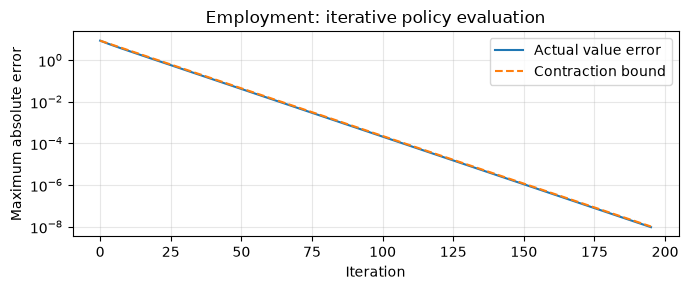

In [9]:
errors = np.max(np.abs(employment_history - employment_value), axis=1)
iterations = np.arange(len(errors))
bound = beta ** iterations * errors[0]

plt.figure(figsize=(7, 3))
plt.semilogy(iterations, errors, label="Actual value error")
plt.semilogy(iterations, bound, "--", label="Contraction bound")
plt.xlabel("Iteration")
plt.ylabel("Maximum absolute error")
plt.title("Employment: iterative policy evaluation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Evaluate the cake-eating policies

A policy fixes the action at every stock. Build its reward vector $r^\sigma$ and transition matrix $P^\sigma$, then use the same linear solver.

The transition is deterministic: place probability `1` in the column for the next stock. State indices and stock values coincide because states are ordered `0, 1, ..., max_stock`.

In [10]:
def cake_policy_arrays(model, policy):
    n = len(model.states)
    P_sigma = np.zeros((n, n))
    r_sigma = np.zeros(n)
    for state in model.states:
        action = policy(state)
        next_state, reward = model.step(state, action)
        P_sigma[state, next_state] = 1
        r_sigma[state] = reward
    return P_sigma, r_sigma


P_all, r_all = cake_policy_arrays(cake, eat_all)
P_one, r_one = cake_policy_arrays(cake, consume_one)
value_all = evaluate_policy(P_all, r_all, cake.beta)
value_one = evaluate_policy(P_one, r_one, cake.beta)
print("P under consume_one:", P_one, sep="\n")
print("Values under eat_all:", value_all)
print("Values under consume_one:", value_one)
assert np.allclose(value_all, [0, 1, np.sqrt(2)])
assert np.allclose(value_one, [0, 1, 1.9])
assert np.isclose(value_all[2], return_all)
assert np.isclose(value_one[2], return_one)

P under consume_one:
[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]
Values under eat_all: [-0.        1.        1.414214]
Values under consume_one: [-0.   1.   1.9]


## 7. Implement the Bellman operator

Now choose the action instead of fixing a policy:

$$(Tv)(k)=\max_{c\in\{0,\ldots,k\}}\{\sqrt c+\beta v(k-c)\}.$$

First calculate each feasible action's current reward plus continuation value. `np.max` returns the best value; `np.argmax` returns its position. Because actions are ordered `0, ..., k`, that position is the consumption choice. Ties select the first maximizing action.

In [11]:
def cake_action_values(model, value, state):
    candidates = []
    for action in range(state + 1):
        next_state, reward = model.step(state, action)
        candidates.append(reward + model.beta * value[next_state])
    return np.array(candidates)


def cake_bellman(model, value):
    new_value = np.zeros(len(model.states))
    for state in model.states:
        new_value[state] = np.max(cake_action_values(model, value, state))
    return new_value


def cake_greedy_policy(model, value):
    policy = np.zeros(len(model.states), dtype=int)
    for state in model.states:
        policy[state] = np.argmax(cake_action_values(model, value, state))
    return policy

## 8. Value iteration and the optimal policy

Pass the Bellman update to `iterate_values`. All states use the previous value vector in each sweep. This reproduces the lecture's cake-eating calculation.

In [12]:
def cake_update(value):
    return cake_bellman(cake, value)


cake_value, cake_history, cake_residual = iterate_values(
    cake_update, np.zeros(len(cake.states)), cake.beta
)
cake_policy = cake_greedy_policy(cake, cake_value)
print("Value iterates (columns are stocks 0, 1, 2):", cake_history, sep="\n")
print("Optimal value:", cake_value)
print("Consumption by stock:", cake_policy)
print("Residual:", cake_residual)
assert np.allclose(cake_history[1], [0, 1, np.sqrt(2)])
assert np.allclose(cake_value, [0, 1, 1.9])
assert np.array_equal(cake_policy, [0, 1, 1])

Value iterates (columns are stocks 0, 1, 2):
[[0.       0.       0.      ]
 [0.       1.       1.414214]
 [0.       1.       1.9     ]]
Optimal value: [0.  1.  1.9]
Consumption by stock: [0 1 1]
Residual: 0.0


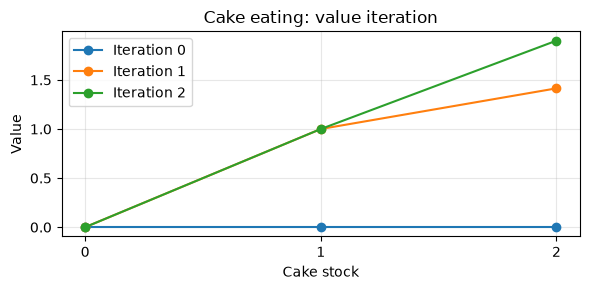

In [13]:
plt.figure(figsize=(6, 3))
for iteration, value in enumerate(cake_history):
    plt.plot(cake.states, value, "o-", label=f"Iteration {iteration}")
plt.xticks(cake.states)
plt.xlabel("Cake stock")
plt.ylabel("Value")
plt.title("Cake eating: value iteration")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Check the recovered policy

Turn the action array into a function, so Lab 1's `simulate` method can use it. Evaluate this policy separately and compare its value with the Bellman solution.

In [14]:
def computed_policy(state):
    return cake_policy[state]


P_computed, r_computed = cake_policy_arrays(cake, computed_policy)
policy_value = evaluate_policy(P_computed, r_computed, cake.beta)
optimal_path, optimal_rewards = cake.simulate(computed_policy, 2, periods=3)
print("Stock path:", optimal_path)
print("Discounted return:", discounted_return(optimal_rewards, cake.beta))
print("Policy value:", policy_value)
assert np.allclose(policy_value, cake_value)
assert np.isclose(discounted_return(optimal_rewards, cake.beta), cake_value[2])

Stock path: [2 1 0 0]
Discounted return: 1.9
Policy value: [-0.   1.   1.9]


## 10. Finite horizon: backward induction

With $H$ decisions and terminal payoff zero, set $V_H=0$ and work backwards: $V_t=TV_{t+1}$. Store both the value and policy at each date.

With one decision remaining, consume everything. With two decisions remaining, saving one unit can be worthwhile. Here the policy can depend on the remaining time.

In [15]:
def cake_backward_induction(model, horizon):
    values = np.zeros((horizon + 1, len(model.states)))
    policies = np.zeros((horizon, len(model.states)), dtype=int)
    for t in range(horizon - 1, -1, -1):
        policies[t] = cake_greedy_policy(model, values[t + 1])
        values[t] = cake_bellman(model, values[t + 1])
    return values, policies


finite_values, finite_policies = cake_backward_induction(cake, horizon=2)
print("Values at dates 0, 1, 2:", finite_values, sep="\n")
print("Policies at dates 0, 1:", finite_policies, sep="\n")
assert np.allclose(finite_values[0], cake_history[2])
assert np.array_equal(finite_policies[1], [0, 1, 2])
assert np.array_equal(finite_policies[0], [0, 1, 1])

Values at dates 0, 1, 2:
[[0.       1.       1.9     ]
 [0.       1.       1.414214]
 [0.       0.       0.      ]]
Policies at dates 0, 1:
[[0 1 1]
 [0 1 2]]


## Exercise 1: Change the employment transition

Write `employment_values(alpha)` with job-loss probability `0.05`, rewards `[0, 1]`, and discount factor `0.9`.

1. Build the transition matrix for the supplied job-finding probability.
2. Evaluate the values using both `evaluate_policy` and `iterate_values`.
3. Return the two value vectors and check that they agree.
4. Run with `alpha=0.40` and check that both values exceed the baseline values.

Complete the code, then uncomment the checks. Use **Show code** to reveal the solution.

In [16]:
def employment_values(alpha):
    # Build P, define an update function, and return both value vectors.
    pass

# direct, iterative = employment_values(0.40)
# print("Direct:", direct, "Iterative:", iterative)
# assert np.allclose(direct, iterative, atol=1e-8, rtol=0)
# assert np.all(direct > employment_value)

In [17]:
#@title Solution 1: Employment values (Show code)
#@markdown Select **Show code** to reveal the solution. Run this cell, then call `employment_solution()` to check it.
def employment_solution():
    def employment_values(alpha):
        assert 0 <= alpha <= 1
        P_new = np.array([[1 - alpha, alpha], [0.05, 0.95]])
        r_new = np.array([0.0, 1.0])
        beta_new = 0.9
        direct = evaluate_policy(P_new, r_new, beta_new)

        def update(value):
            return r_new + beta_new * P_new @ value

        iterative, history, residual = iterate_values(update, np.zeros(2), beta_new)
        return direct, iterative

    direct, iterative = employment_values(0.40)
    assert np.allclose(direct, iterative, atol=1e-8, rtol=0)
    assert np.all(direct > employment_value)
    print("Direct:", direct, "Iterative:", iterative)
    return direct, iterative

## Exercise 2: Solve a larger cake-eating problem

Return to Lab 1's stock of **4 units** and discount factor **0.95**.

1. Complete `solve_cake(max_stock, beta)` using the supplied Bellman and iteration functions. Return the value vector and greedy action array.
2. Print the policy at every stock and simulate it from 4 units.
3. Evaluate the computed policy using `cake_policy_arrays` and `evaluate_policy`; check agreement with the value-iteration result.
4. Compare its value with the feasible `consume_one` policy at every stock.

Keep all work in code. The solution block uses separate local definitions.

In [18]:
def solve_cake(max_stock, beta):
    # Create the model, define its Bellman update, and run value iteration.
    # Return the value vector and the greedy action array.
    pass

# large_cake = CakeMDP(max_stock=4, beta=0.95)
# large_value, large_policy = solve_cake(4, 0.95)
# print("Values:", large_value)
# print("Consumption:", large_policy)
# Define a policy function using large_policy[state], then evaluate and simulate it.

In [19]:
#@title Solution 2: Larger cake-eating problem (Show code)
#@markdown Select **Show code** to reveal the solution. Run this cell, then call `larger_cake_solution()` to check it.
def larger_cake_solution():
    def solve_cake(max_stock, beta):
        model = CakeMDP(max_stock=max_stock, beta=beta)

        def update(value):
            return cake_bellman(model, value)

        value, history, residual = iterate_values(update, np.zeros(len(model.states)), beta)
        return value, cake_greedy_policy(model, value)

    model = CakeMDP(max_stock=4, beta=0.95)
    value, policy = solve_cake(4, 0.95)

    def optimal_policy(state):
        return policy[state]

    P_opt, r_opt = cake_policy_arrays(model, optimal_policy)
    evaluated = evaluate_policy(P_opt, r_opt, model.beta)
    P_one, r_one = cake_policy_arrays(model, consume_one)
    one_value = evaluate_policy(P_one, r_one, model.beta)
    path, rewards = model.simulate(optimal_policy, 4, periods=5)
    assert np.allclose(value, evaluated, atol=1e-8, rtol=0)
    assert np.all(value >= one_value - 1e-8)
    assert path[-1] == 0
    assert np.isclose(discounted_return(rewards, model.beta), value[4])
    print("Values:", value)
    print("Consumption:", policy)
    print("Stock path:", path)
    print("Rewards:", rewards)
    return value, policy, path

## Save your work

Restart the runtime and run all cells after completing the exercises. Save and download the notebook; keep it with your Git project. The companion `value_functions.py` contains the same code in order. Reference solution functions run only when called.

## References

1. **Richard S. Sutton and Andrew G. Barto (2018), [Reinforcement Learning: An Introduction](https://www.andrew.cmu.edu/course/10-703/textbook/BartoSutton.pdf). 2nd ed. MIT Press. [Book]** Chapters 3 and 4: returns, policy evaluation, and value iteration.
2. **Thomas J. Sargent and John Stachurski, [QuantEcon](https://quantecon.org/lectures/). [Online lectures]** [Discrete State Dynamic Programming](https://tools-techniques.quantecon.org/discrete_dp.html).

These sources are included in the [course reference list](https://yaolangzhong.github.io/U_Tokyo_Comp_Econ_Course/references.html).